# TiDE Training Pipeline — Calibrated Uncertainty Surrogate

One-shot **M-step quantile forecaster** for the COBR. Same 3922-D input as MSA-NARX
(3796 past window + 14×9 future covariates), but outputs a **(M, 26, 3)** tensor:
lower / median / upper quantile per output per horizon.

- **Quantile (pinball) loss** at τ = [0.05, 0.50, 0.95] → 90% prediction interval
- **CQR** (Conformalized Quantile Regression) post-hoc corrects coverage using a held-out
  calibration split → finite-sample coverage guarantee (the gap Chen et al. leave open)
- **4-way simulation split**: train / val / calibration / test
- Evaluation: per-horizon median R²/RMSE, coverage, sharpness, CRPS, AR-rollout tube coverage

Outputs → `Models_TiDE/version_X/`, logs → `logs/TiDE/`.


In [1]:
# Cell 1 - Imports
import os, sys, shutil, torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger

torch.set_float32_matmul_precision('high')
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../..'))

from common.shared_helpers.helper_classes_MSA import GeLU
from common.shared_helpers.helpers_MSA import (
    load_narx_dataset_with_metadata,
    load_scaler_params, save_scaler_params,
    scale_data, get_standard_trainer, save_model_metadata,
    get_latest_version_dir, create_next_version_dir,
    visualize_training_logs, filter_narx_data_by_vars, build_msa_dataset,
)
from helpers.TiDE_helpers import (
    TiDE, PinballLoss, get_simulation_split_dataloaders_4way,
    evaluate_tide_on_test_set, calibrate_cqr, calibrate_cqr_ar, apply_cqr,
    probabilistic_metrics, recursive_tide_rollout,
    collect_ar_rollouts, make_step_bins, step_bin_ids,
    cqr_qhat_stepwise, apply_cqr_stepwise, cqr_qhat_safety,
)

print(f'PyTorch  : {torch.__version__}')
print(f'Lightning: {pl.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

W0617 17:37:29.064000 42788 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


PyTorch  : 2.11.0+cu128
Lightning: 2.6.1
CUDA available: True


In [2]:
# Cell 2 - config
DATASET_PATH = '../../Data_Sampling/datasets/21_05_2026/narx/thermal_narx_dataset_3.h5'
RAW_HDF5 = '../../Data_Sampling/datasets/21_05_2026/thermal_cobr_raw_data.h5'

M = 15
INCLUDE_HP_INT = True

TAU = [0.05, 0.50, 0.95] # 90% pred interval
ALPHA = 0.10             # 90% coverage
BURN_IN = 150            # Skip first BURN_IN steps for AR-CQR calibration
BIN_WIDTH = 250          # AR step-bin width (absolute rollout steps) for step-adaptive CQR

# Output groups (Mondrian) for group-conditional coverage + reactor safety band.
# 26 outputs: reactor[0:9], thermostat[9:17], heating[17:25], T_reactor_max[25].
GROUPS = {'reactor': slice(0, 9), 'thermostat': slice(9, 17),
          'heating': slice(17, 25), 'T_reactor_max': slice(25, 26)}
SAFETY_CHANNELS = list(range(9)) + [25]   # reactor zones + T_reactor_max (constraint-relevant)

CALIB_FROM_VERSION = 'version_0' # set to None for fresh model

STATE_GROUP_DIMS = [9, 8] 
N_CTRL_DIMS = 9

TRAIN_FRAC = 0.60
VAL_FRAC = 0.10
CALIB_FRAC = 0.15 # test_frac = 0.15 (remainder)
SPLIT_SEED = 42

# TiDE Arch -- 
HIDDEN_DIM         = 512
DECODER_OUTPUT_DIM = 32
TEMPORAL_WIDTH     = 16
NUM_ENCODER_LAYERS = 2
NUM_DECODER_LAYERS = 2
DROPOUT            = 0.1
NOISE_SIGMA        = 0.05

LEARNING_RATE = 1e-4
MAX_EPOCHS     = 500
BATCH_SIZE    = 8192

GRADIENT_CLIP_VAL           = 0.5
GRADIENT_CLIP_ALGORITHM     = 'norm'
EARLY_STOPPING_PATIENCE     = 25
EARLY_STOPPING_MIN_DELTA    = 0.001
USE_STANDARD_EARLY_STOPPING = False

LOG_DIR     = 'logs/TiDE'
EXPERIMENT  = 'TiDE'
MODELS_BASE = 'Models_TiDE'
RESUME      = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ACCELERATOR = 'gpu' if DEVICE == 'cuda' else 'cpu'

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODELS_BASE, exist_ok=True)
print(f'Device : {DEVICE} | M={M} | quantiles={TAU} | alpha={ALPHA}')
print(f'Outputs: {26 if INCLUDE_HP_INT else 17} base | split {TRAIN_FRAC}/{VAL_FRAC}/{CALIB_FRAC}/rest')

Device : cuda | M=15 | quantiles=[0.05, 0.5, 0.95] | alpha=0.1
Outputs: 26 base | split 0.6/0.1/0.15/rest


In [3]:
# Cell 3 -- load dataset 
data, metadata = load_narx_dataset_with_metadata(DATASET_PATH)
print('Data arrays:')
for k, v in data.items():
    print(f'  {k}: {tuple(v.shape)}')

label_names = []
if 'labels' in metadata:
    for vm in metadata['labels']:
        name = vm['name']; nd = vm.get('selected_dims', 1)
        label_names.extend([f'{name}[{i}]' for i in range(nd)] if nd > 1 else [name])
print(f'\nLabel columns ({len(label_names)}): {label_names[:3]} ... {label_names[-3:]}')

Data arrays:
  input_features: (1124247, 9)
  labels: (1124247, 26)
  narx_state_features: (1124247, 3796)
  sim_sample_counts: (499,)

Label columns (26): ['T_reactor_meas[0]', 'T_reactor_meas[1]', 'T_reactor_meas[2]'] ... ['heating_power_avg[6]', 'heating_power_avg[7]', 'T_reactor']


In [4]:
# Cell 4 -- Scale features/labels/inputs
features_t       = data['narx_state_features'].float()
labels_t         = data['labels'].float()
input_features_t = data['input_features'].float()

_EXCLUDE = [] if INCLUDE_HP_INT else ['heating_power_avg']
features_t, labels_t, label_names, active_metadata = filter_narx_data_by_vars(
    features_t, labels_t, metadata, exclude_var_names=_EXCLUDE)
print(f'Feature dim: {features_t.shape[1]} | Label dim: {labels_t.shape[1]} | Input dim: {input_features_t.shape[1]}')


feat_scaler_path       = os.path.join(LOG_DIR, 'feature_scaler.yml')
label_scaler_path      = os.path.join(LOG_DIR, 'label_scaler.yml')
input_feat_scaler_path = os.path.join(LOG_DIR, 'input_feature_scaler.yml')

features_scaled, feat_scaler             = scale_data(features_t.numpy(), save_path=feat_scaler_path)
labels_scaled, label_scaler              = scale_data(labels_t.numpy(), save_path=label_scaler_path)
input_features_scaled, input_feat_scaler = scale_data(input_features_t.numpy(), save_path=input_feat_scaler_path)

print(f'NARX feats {tuple(features_scaled.shape)} | labels {tuple(labels_scaled.shape)} | inputs {tuple(input_features_scaled.shape)}')


Feature dim: 3796 | Label dim: 26 | Input dim: 9
NARX feats (1124247, 3796) | labels (1124247, 26) | inputs (1124247, 9)


In [5]:
# Cell 5 -- MSA Dataset + 4-way split
import h5py
with h5py.File(DATASET_PATH, 'r') as _f:
    sim_sample_counts = np.array(_f['sim_sample_counts'], dtype=np.int64)

msa_features_np, msa_labels_np, msa_sim_counts = build_msa_dataset(
    features_scaled.numpy(), labels_scaled.numpy(), input_features_scaled.numpy(),
    sim_sample_counts, M=M)

# Combined MSA feature scaler (analytic: tile input scaler M-1 times — no re-fit)
msa_feat_scaler = {
    'mean': np.concatenate([feat_scaler['mean'], np.tile(input_feat_scaler['mean'], M - 1)]),
    'std':  np.concatenate([feat_scaler['std'],  np.tile(input_feat_scaler['std'],  M - 1)]),
}
save_scaler_params(os.path.join(LOG_DIR, 'msa_feature_scaler.yml'), msa_feat_scaler)

msa_features_t = torch.from_numpy(msa_features_np).float()
msa_labels_t   = torch.from_numpy(msa_labels_np).float()
n_outputs = labels_scaled.shape[1]   # 26

print(f'MSA features {tuple(msa_features_t.shape)} | labels {tuple(msa_labels_t.shape)}')
print(f'Expected feat dim {features_scaled.shape[1] + (M-1)*N_CTRL_DIMS}, label dim {n_outputs*M}')

train_loader, val_loader, calib_loader, test_loader, split_info = get_simulation_split_dataloaders_4way(
    msa_features_t, msa_labels_t, sim_sample_counts=msa_sim_counts,
    train_frac=TRAIN_FRAC, val_frac=VAL_FRAC, calib_frac=CALIB_FRAC,
    batch_size=BATCH_SIZE, seed=SPLIT_SEED, multiprocessing=False)

# calib/test loaders use shuffle=False, so torch.cat preserves the contiguous per-sim
# order in split_info — required for AR-CQR per-sim rollout alignment.
X_test  = torch.cat([xb for xb, _ in test_loader]);  y_test  = torch.cat([yb for _, yb in test_loader])
X_calib = torch.cat([xb for xb, _ in calib_loader]); y_calib = torch.cat([yb for _, yb in calib_loader])
print(f'Test  tensors: X={tuple(X_test.shape)}  y={tuple(y_test.shape)}')
print(f'Calib tensors: X={tuple(X_calib.shape)} y={tuple(y_calib.shape)}')

# sanity: calib_sim_counts must sum to len(X_calib)
assert split_info['calib_sim_counts'].sum() == X_calib.shape[0], 'calib sim-count mismatch'
print(f"Calib sims: {len(split_info['calib_sim_counts'])} | "
      f"Test sims: {len(split_info['test_sim_counts'])}")

MSA features (1117261, 3922) | labels (1117261, 390)
Expected feat dim 3922, label dim 390
Sim split (seed=42): 299 train (669,461) | 49 val (109,711) | 74 calib (165,686) | 77 test (172,403)
Test  tensors: X=(172403, 3922)  y=(172403, 390)
Calib tensors: X=(165686, 3922) y=(165686, 390)
Calib sims: 74 | Test sims: 77


In [6]:
# Cell 6 -- Build / load model

past_dim = features_scaled.shape[1]
future_cov_dim = (M - 1) * N_CTRL_DIMS

network_hp = {
    'past_dim':           past_dim,
    'future_cov_dim':     future_cov_dim,
    'M':                  M,
    'base_output_dim':    n_outputs,
    'hidden_dim':         HIDDEN_DIM,
    'decoder_output_dim': DECODER_OUTPUT_DIM,
    'temporal_width':     TEMPORAL_WIDTH,
    'num_encoder_layers': NUM_ENCODER_LAYERS,
    'num_decoder_layers': NUM_DECODER_LAYERS,
    'dropout':            DROPOUT,
    'activation':         GeLU(),
    'quantiles':          TAU,
    'noise_sigma':        NOISE_SIGMA,
}

training_hp = {
    'loss_function':    PinballLoss(TAU),
    'optimizer_class':  torch.optim.Adam,
    'optimizer_kwargs': {'lr': LEARNING_RATE},
    'scheduler_class':  torch.optim.lr_scheduler.ReduceLROnPlateau,
    'scheduler_kwargs': {'factor': 0.5, 'patience': 10},
}

if CALIB_FROM_VERSION is None:
    model = TiDE(network_hp, training_hp)
else:
    # ver_1 = AR-calibrated variant of ver_0: reuse the trained weights, no retraining.
    _load_pt = os.path.join(MODELS_BASE, CALIB_FROM_VERSION, 'tide_model_full.pt')
    model = torch.load(_load_pt, weights_only=False)
    print(f'Loaded {CALIB_FROM_VERSION} weights from {_load_pt} (calibration-only, no retraining)')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable Parameters: {n_params:,}')

# Quick sanity check on a small batch --
_out = model(X_test[:4])
print(f'Output shape: {tuple(_out.shape)}  (expect (4, {M}, {n_outputs}, {len(TAU)}))')
assert (_out[..., 0] <= _out[..., 1]).all() and (_out[..., 1] <= _out[..., 2]).all(), 'quantile crossing!'
print('Monotonicity OK: lower <= median <= upper')
print(f'PinballLoss on batch: {PinballLoss(TAU)(_out, y_test[:4]).item():.4f}')

Loaded version_0 weights from Models_TiDE\version_0\tide_model_full.pt (calibration-only, no retraining)
TiDE(
  (loss_function): PinballLoss()
  (cov_proj): Linear(in_features=9, out_features=16, bias=True)
  (encoder): ModuleList(
    (0): ResidualBlock(
      (lin1): Linear(in_features=4036, out_features=512, bias=True)
      (act): GeLU()
      (drop): Dropout(p=0.1, inplace=False)
      (lin2): Linear(in_features=512, out_features=512, bias=True)
      (skip): Linear(in_features=4036, out_features=512, bias=True)
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (1): ResidualBlock(
      (lin1): Linear(in_features=512, out_features=512, bias=True)
      (act): GeLU()
      (drop): Dropout(p=0.1, inplace=False)
      (lin2): Linear(in_features=512, out_features=512, bias=True)
      (skip): Identity()
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
  )
  (decoder): ModuleList(
    (0): ResidualBlock(
      (lin1): Linear(in_feat

In [7]:
# Cell 7 -- Train (skipped when loading ver_0 for calibration)
if CALIB_FROM_VERSION is not None:
    print(f'CALIB_FROM_VERSION={CALIB_FROM_VERSION} -- skipping training, reusing loaded weights.')
else:
    logger = TensorBoardLogger(save_dir=LOG_DIR, name=EXPERIMENT)

    ckpt_path = None
    if RESUME:
        exp_dir = os.path.join(LOG_DIR, EXPERIMENT)
        if os.path.isdir(exp_dir):
            try:
                vdir = get_latest_version_dir(exp_dir)
                last = os.path.join(vdir, 'checkpoints', 'last.ckpt')
                if os.path.exists(last):
                    ckpt_path = last; print(f'Resume from {last}')
            except Exception:
                print('No prior version -- fresh start')

    trainer = get_standard_trainer(
        logger=logger, max_epochs=MAX_EPOCHS, accelerator=ACCELERATOR,
        gradient_clip_val=GRADIENT_CLIP_VAL, gradient_clip_algorithm=GRADIENT_CLIP_ALGORITHM,
        patience=EARLY_STOPPING_PATIENCE, min_delta=EARLY_STOPPING_MIN_DELTA,
        use_standard_early_stopping=USE_STANDARD_EARLY_STOPPING
    )

    trainer.fit(model, train_loader, val_loader, ckpt_path=ckpt_path)

CALIB_FROM_VERSION=version_0 -- skipping training, reusing loaded weights.


In [8]:
# Cell 8 -- Save model + scalers
MODEL_SAVE_DIR = create_next_version_dir(MODELS_BASE)
_scaler_files = ('feature_scaler.yml', 'label_scaler.yml',
                 'input_feature_scaler.yml', 'msa_feature_scaler.yml')

if CALIB_FROM_VERSION is None:
    pt_path = os.path.join(MODEL_SAVE_DIR, 'tide_model_full.pt')
    torch.save(model, pt_path)
    print(f'Model saved: {pt_path}')
    _scaler_src_dir = LOG_DIR
else:
    # ver_1: copy ver_0 weights unchanged (no retraining) + its scalers
    _src_pt = os.path.join(MODELS_BASE, CALIB_FROM_VERSION, 'tide_model_full.pt')
    shutil.copy2(_src_pt, os.path.join(MODEL_SAVE_DIR, 'tide_model_full.pt'))
    print(f'Copied {CALIB_FROM_VERSION} weights -> {MODEL_SAVE_DIR}')
    _scaler_src_dir = os.path.join(MODELS_BASE, CALIB_FROM_VERSION)

for sc in _scaler_files:
    src = os.path.join(_scaler_src_dir, sc)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(MODEL_SAVE_DIR, sc))
print(f'Scalers copied to {MODEL_SAVE_DIR}')

Copied version_0 weights -> Models_TiDE\version_2
Scalers copied to Models_TiDE\version_2


In [9]:
# Cell 9 -- Metadata save
model_config = {
    'network_hyperparameters': {k: (type(v).__name__ if k == 'activation' else v)
                                for k, v in network_hp.items()},
    'training_hyperparameters': {
        'loss_function': type(training_hp['loss_function']).__name__,
        'optimizer': training_hp['optimizer_class'].__name__,
        'learning_rate': LEARNING_RATE, 'batch_size': BATCH_SIZE, 'max_epochs': MAX_EPOCHS,
        'scheduler': training_hp['scheduler_class'].__name__,
    },
    'data_split': {'method': 'simulation-wise-4way',
                   'train': TRAIN_FRAC, 'val': VAL_FRAC, 'calib': CALIB_FRAC, 'seed': SPLIT_SEED},
    'quantiles': TAU, 'alpha': ALPHA, 'burn_in': BURN_IN,
    'calib_from_version': CALIB_FROM_VERSION,
    'include_hp_int': INCLUDE_HP_INT, 'label_names': label_names,
    'M': M, 'base_output_dim': n_outputs,
    'n_ctrl_dims': N_CTRL_DIMS, 'state_group_dims': STATE_GROUP_DIMS,
}

if CALIB_FROM_VERSION is None:
    version_dir = get_latest_version_dir(os.path.join(LOG_DIR, EXPERIMENT))
    save_model_metadata(version_dir, active_metadata, model_config, DATASET_PATH)
    for fname in ('model_metadata.yml', 'metrics.csv'):
        src = os.path.join(version_dir, fname)
        if os.path.exists(src):
            shutil.copy2(src, os.path.join(MODEL_SAVE_DIR, fname))
else:
    # ver_1: inherit ver_0's metadata/metrics; record the AR-calibration config separately
    for fname in ('model_metadata.yml', 'metrics.csv'):
        src = os.path.join(MODELS_BASE, CALIB_FROM_VERSION, fname)
        if os.path.exists(src):
            shutil.copy2(src, os.path.join(MODEL_SAVE_DIR, fname))
    import yaml
    with open(os.path.join(MODEL_SAVE_DIR, 'ar_calibration_config.yml'), 'w') as _f:
        yaml.safe_dump({'calib_from_version': CALIB_FROM_VERSION,
                        'quantiles': TAU, 'alpha': ALPHA, 'burn_in': BURN_IN,
                        'method': 'AR-rollout CQR (constant per-output q_hat)'}, _f)
print(f'Metadata saved & copied to {MODEL_SAVE_DIR}')

Metadata saved & copied to Models_TiDE\version_2


In [10]:
# Cell 10 -- Per-Horizon median evaluation
results = evaluate_tide_on_test_set(
    model, X_test, y_test, label_scaler_params=label_scaler,
    M=M, base_output_dim=n_outputs, quantiles=TAU, device=DEVICE)
metrics_df = results['metrics_df']

for horizon in [1, M]:
    hi = horizon - 1
    ph = results['median'][:, hi, :]; gh = results['ground_truth'][:, hi, :]
    ss_res = np.sum((gh - ph) ** 2, axis=0); ss_tot = np.sum((gh - gh.mean(0)) ** 2, axis=0)
    r2 = 1 - ss_res / (ss_tot + 1e-12); rmse = np.sqrt(np.mean((ph - gh) ** 2, axis=0))
    print(f'\n--- Horizon {horizon} per-output (median) ---')
    print(f"{'Output':<28}{'RMSE':>9}{'R2':>9}"); print('-' * 46)
    for i, nm in enumerate(label_names):
        print(f'{nm:<28}{rmse[i]:9.4f}{r2[i]:9.4f}')

_res_path = os.path.join(MODEL_SAVE_DIR, 'Results.txt')
with open(_res_path, 'w') as f:
    f.write(f'TiDE  M={M}  base_output_dim={n_outputs}  quantiles={TAU}  alpha={ALPHA}\n')
    f.write(f'Dataset: {DATASET_PATH}\n\nPer-horizon median summary:\n')
    f.write(metrics_df.to_string(index=False)); f.write('\n')
print(f'\nResults saved: {_res_path}')


--- TiDE Median Evaluation (per horizon) ---
 Horizon       R2     RMSE      MAE
       1 0.999338 2.230706 0.940983
       2 0.999418 1.994241 0.854621
       3 0.999442 1.876274 0.807378
       4 0.999447 1.797153 0.778342
       5 0.999452 1.772297 0.770177
       6 0.999452 1.764385 0.766319
       7 0.999456 1.761887 0.764948
       8 0.999456 1.748857 0.758049
       9 0.999461 1.735490 0.752207
      10 0.999458 1.726442 0.749207
      11 0.999458 1.718686 0.746550
      12 0.999462 1.690377 0.730875
      13 0.999474 1.577353 0.683749
      14 0.999477 1.438429 0.634088
      15 0.999412 1.726148 0.723332

--- Horizon 1 per-output (median) ---
Output                           RMSE       R2
----------------------------------------------
T_reactor_meas[0]              0.0189   1.0000
T_reactor_meas[1]              0.0245   1.0000
T_reactor_meas[2]              0.0244   1.0000
T_reactor_meas[3]              0.0256   1.0000
T_reactor_meas[4]              0.0312   1.0000
T_reactor_

In [11]:
# Cell 11 -- CQR Calibration (one-shot + AR: constant / step-adaptive / safety)
import yaml

# (a) One-shot CQR on the true-window calib regime -> q_hat (M, O).
q_hat = calibrate_cqr(
    model, X_calib, y_calib, label_scaler_params=label_scaler,
    M=M, base_output_dim=n_outputs, quantiles=TAU, device=DEVICE, alpha=ALPHA)
np.save(os.path.join(MODEL_SAVE_DIR, 'cqr_qhat.npy'), q_hat)
print(f'q_hat shape {q_hat.shape} saved to {MODEL_SAVE_DIR}/cqr_qhat.npy')

# (b) ONE AR calib-rollout pass over all calib sims -> derive every AR band from it.
coll_cal = collect_ar_rollouts(
    model, X_calib, y_calib, split_info['calib_sim_counts'],
    feature_scaler_params=msa_feat_scaler, label_scaler_params=label_scaler,
    state_group_dims=STATE_GROUP_DIMS, n_ctrl_dims=N_CTRL_DIMS,
    M=M, base_output_dim=n_outputs, quantiles=TAU, device=DEVICE, burn_in=BURN_IN)
S_cal = np.maximum(coll_cal['lower'] - coll_cal['ground_truth'],
                   coll_cal['ground_truth'] - coll_cal['upper'])     # (N_cal, O)

# constant per-output band (== legacy calibrate_cqr_ar result)
n_cal = S_cal.shape[0]
_lvl = min(1.0, (1 - ALPHA) * (1 + 1.0 / n_cal))
q_hat_ar = np.quantile(S_cal, _lvl, axis=0, method='higher')         # (O,)
print(f'AR-CQR: {coll_cal["n_sims_used"]} sims, n_scores={n_cal} (k>={BURN_IN}), '
      f'level={_lvl:.5f}, q_hat_ar range [{q_hat_ar.min():.3f}, {q_hat_ar.max():.3f}]')

# step-adaptive band: q_hat per (step-bin, output)
bin_edges, bin_ids_cal = make_step_bins(coll_cal['step_idx'], bin_width=BIN_WIDTH, burn_in=BURN_IN)
n_bins = len(bin_edges)
q_hat_ar_stepwise = cqr_qhat_stepwise(S_cal, bin_ids_cal, n_bins, alpha=ALPHA)   # (n_bins, O)

# reactor safety band: Mondrian-max over reactor zones + T_reactor_max
q_hat_ar_safety = cqr_qhat_safety(q_hat_ar, SAFETY_CHANNELS)                     # (O,)

np.save(os.path.join(MODEL_SAVE_DIR, 'cqr_qhat_ar.npy'),          q_hat_ar)
np.save(os.path.join(MODEL_SAVE_DIR, 'cqr_qhat_ar_stepwise.npy'), q_hat_ar_stepwise)
np.save(os.path.join(MODEL_SAVE_DIR, 'cqr_qhat_ar_safety.npy'),   q_hat_ar_safety)
print(f'Saved cqr_qhat_ar (O,), cqr_qhat_ar_stepwise {q_hat_ar_stepwise.shape}, '
      f'cqr_qhat_ar_safety (O,)')
print(f'Step bins ({n_bins}, width {BIN_WIDTH}): edges={bin_edges.tolist()}')

# AR eval config -- reused at eval time so test steps map to the SAME bins.
_ar_cfg = {
    'alpha': ALPHA, 'burn_in': BURN_IN, 'bin_width': BIN_WIDTH,
    'n_bins': int(n_bins), 'bin_edges': [int(e) for e in bin_edges],
    'safety_channels': SAFETY_CHANNELS,
    'groups': {k: [int(v.start), int(v.stop)] for k, v in GROUPS.items()},
    'seed': SPLIT_SEED, 'calib_sims': int(coll_cal['n_sims_used']),
    'n_calib_scores': int(n_cal), 'source_version': CALIB_FROM_VERSION,
}
with open(os.path.join(MODEL_SAVE_DIR, 'ar_eval_config.yml'), 'w') as _f:
    yaml.safe_dump(_ar_cfg, _f, sort_keys=False)
print(f'ar_eval_config.yml saved to {MODEL_SAVE_DIR}')

# AR (constant) vs one-shot (horizon-1) inflation per output.
print(f"\n{'Output':<28}{'q_hat[h1]':>12}{'q_hat_ar':>12}{'q_ar_safe':>12}{'ratio':>8}")
for i, nm in enumerate(label_names):
    print(f'{nm:<28}{q_hat[0, i]:12.4f}{q_hat_ar[i]:12.4f}{q_hat_ar_safety[i]:12.4f}'
          f'{q_hat_ar[i] / (q_hat[0, i] + 1e-12):8.2f}')

CQR: n_calib=165686, level=0.90001, q_hat range [-6.447, 0.113]
q_hat shape (15, 26) saved to Models_TiDE\version_2/cqr_qhat.npy
AR-CQR: 74 sims, n_scores=154586 (k>=150), level=0.90001, q_hat_ar range [-0.888, 0.292]
Saved cqr_qhat_ar (O,), cqr_qhat_ar_stepwise (9, 26), cqr_qhat_ar_safety (O,)
Step bins (9, width 250): edges=[150, 400, 650, 900, 1150, 1400, 1650, 1900, 2150]
ar_eval_config.yml saved to Models_TiDE\version_2

Output                         q_hat[h1]    q_hat_ar   q_ar_safe   ratio
T_reactor_meas[0]                -0.0536      0.0209      0.1853   -0.39
T_reactor_meas[1]                -0.0637      0.0206      0.1853   -0.32
T_reactor_meas[2]                -0.0578      0.0297      0.1853   -0.51
T_reactor_meas[3]                -0.0574      0.0228      0.1853   -0.40
T_reactor_meas[4]                -0.0659      0.0190      0.1853   -0.29
T_reactor_meas[5]                -0.0659      0.0346      0.1853   -0.53
T_reactor_meas[6]                -0.0649      0.0620      0

              output  cov_raw  width_raw  cov_cqr  width_cqr     CRPS
   T_reactor_meas[0] 0.996936   0.164628 0.884987   0.058953 0.003467
   T_reactor_meas[1] 0.992721   0.194190 0.883579   0.081853 0.004253
   T_reactor_meas[2] 0.992926   0.192321 0.871086   0.072501 0.004239
   T_reactor_meas[3] 0.994313   0.208500 0.881425   0.082645 0.004616
   T_reactor_meas[4] 0.993095   0.243011 0.877030   0.102350 0.005608
   T_reactor_meas[5] 0.988593   0.259174 0.874519   0.115178 0.006215
   T_reactor_meas[6] 0.988673   0.277341 0.870452   0.128757 0.006834
   T_reactor_meas[7] 0.991022   0.273971 0.890177   0.139245 0.006809
   T_reactor_meas[8] 0.988701   0.163840 0.878991   0.071866 0.003876
T_thermostat_meas[0] 0.963076   1.104053 0.902107   0.820603 0.030666
T_thermostat_meas[1] 0.963949   1.112421 0.899067   0.815235 0.031275
T_thermostat_meas[2] 0.963511   1.082706 0.899149   0.789664 0.029892
T_thermostat_meas[3] 0.965353   1.089771 0.900180   0.792649 0.030214
T_thermostat_meas[4]

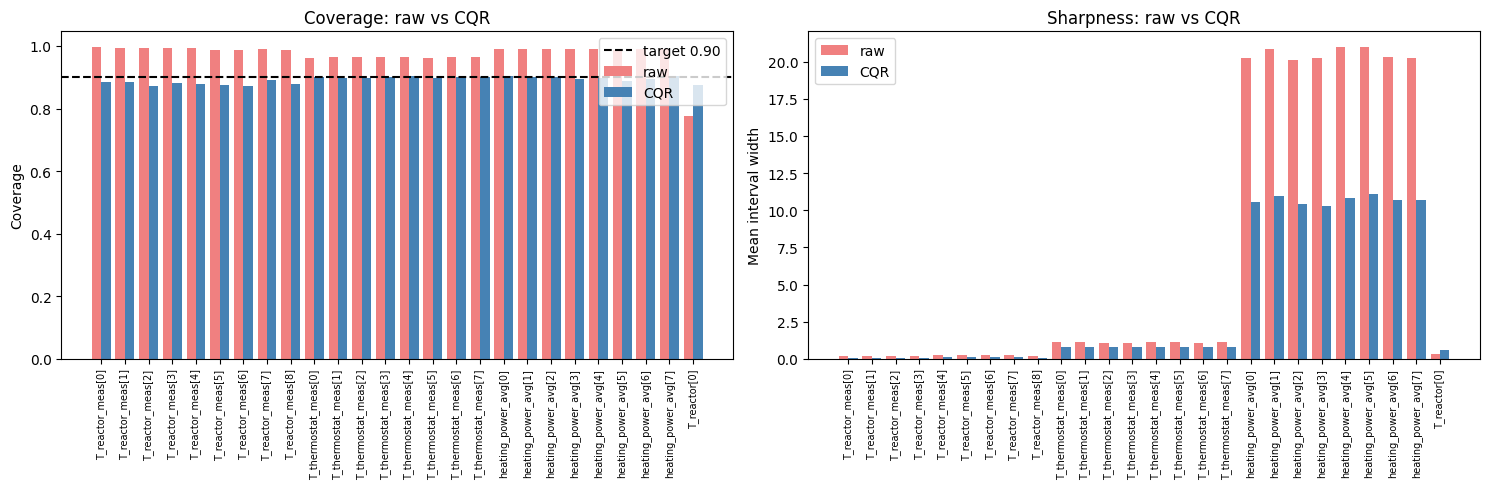

In [12]:
# Cell 12 -- Metrics raw v/s CQR
median    = results['median']; lower_raw = results['lower']; upper_raw = results['upper']
y_phys    = results['ground_truth']; quant_preds = results['predictions']

lower_cqr, upper_cqr = apply_cqr(lower_raw, upper_raw, q_hat)

df_raw = probabilistic_metrics(lower_raw, upper_raw, y_phys, label_names,
                               quantile_preds=quant_preds, quantiles=TAU)
df_cqr = probabilistic_metrics(lower_cqr, upper_cqr, y_phys, label_names,
                               quantile_preds=quant_preds, quantiles=TAU)

cmp = df_raw[['output', 'coverage', 'mean_width']].rename(
        columns={'coverage': 'cov_raw', 'mean_width': 'width_raw'})
cmp['cov_cqr']   = df_cqr['coverage'].values
cmp['width_cqr'] = df_cqr['mean_width'].values
cmp['CRPS']      = df_raw['CRPS'].values
print(cmp.to_string(index=False))
print(f"\nMean coverage  raw={cmp['cov_raw'].mean():.3f}  cqr={cmp['cov_cqr'].mean():.3f}  (target {1-ALPHA:.2f})")
print(f"Mean width     raw={cmp['width_raw'].mean():.3f}  cqr={cmp['width_cqr'].mean():.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(label_names))
ax1.bar(x - 0.2, cmp['cov_raw'], 0.4, label='raw', color='lightcoral')
ax1.bar(x + 0.2, cmp['cov_cqr'], 0.4, label='CQR', color='steelblue')
ax1.axhline(1 - ALPHA, ls='--', color='k', label=f'target {1-ALPHA:.2f}')
ax1.set_xticks(x); ax1.set_xticklabels(label_names, rotation=90, fontsize=7)
ax1.set_ylabel('Coverage'); ax1.set_title('Coverage: raw vs CQR'); ax1.legend()
ax2.bar(x - 0.2, cmp['width_raw'], 0.4, label='raw', color='lightcoral')
ax2.bar(x + 0.2, cmp['width_cqr'], 0.4, label='CQR', color='steelblue')
ax2.set_xticks(x); ax2.set_xticklabels(label_names, rotation=90, fontsize=7)
ax2.set_ylabel('Mean interval width'); ax2.set_title('Sharpness: raw vs CQR'); ax2.legend()
fig.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'cqr_coverage_sharpness.png'), dpi=150)
plt.show()

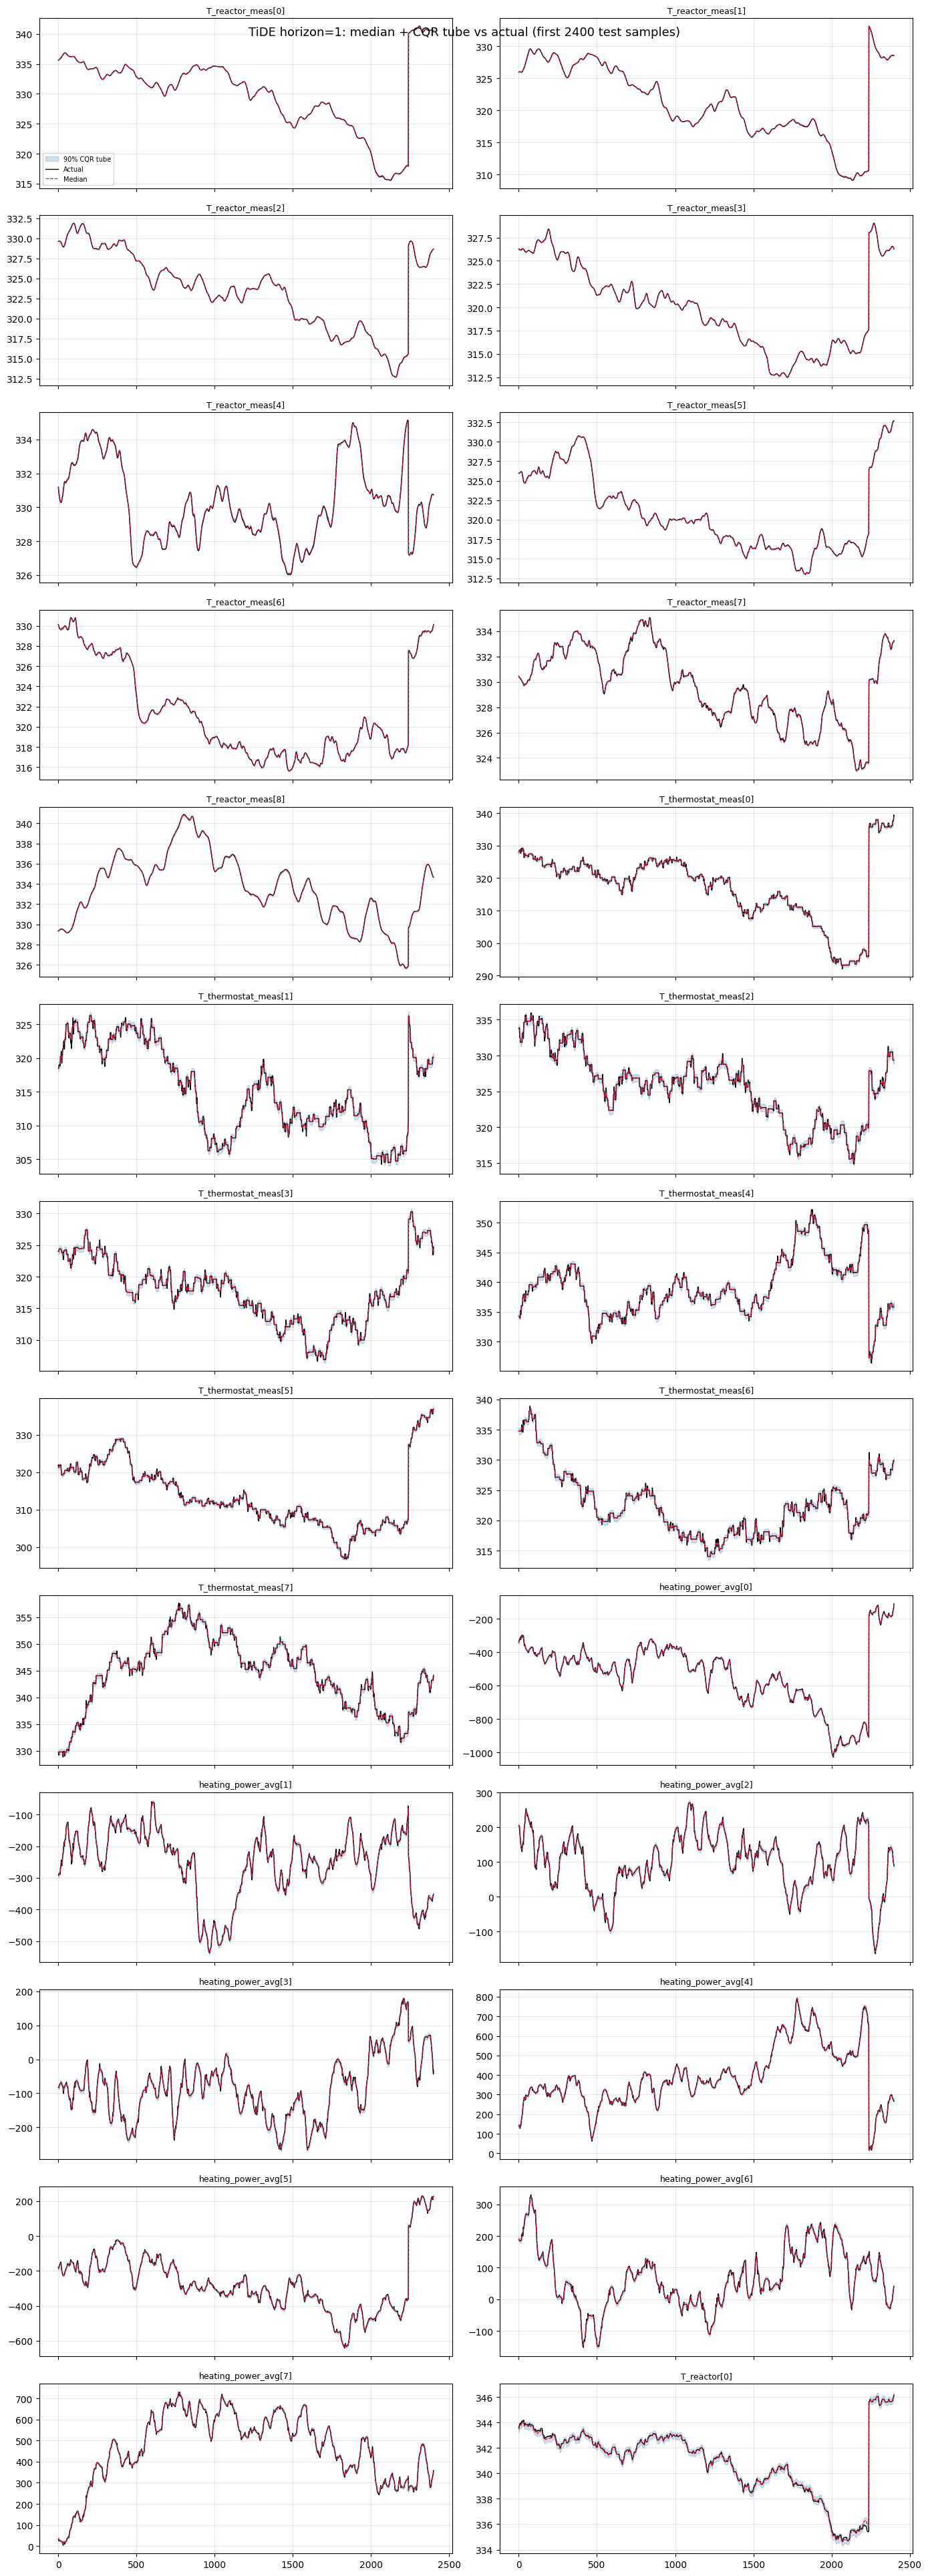

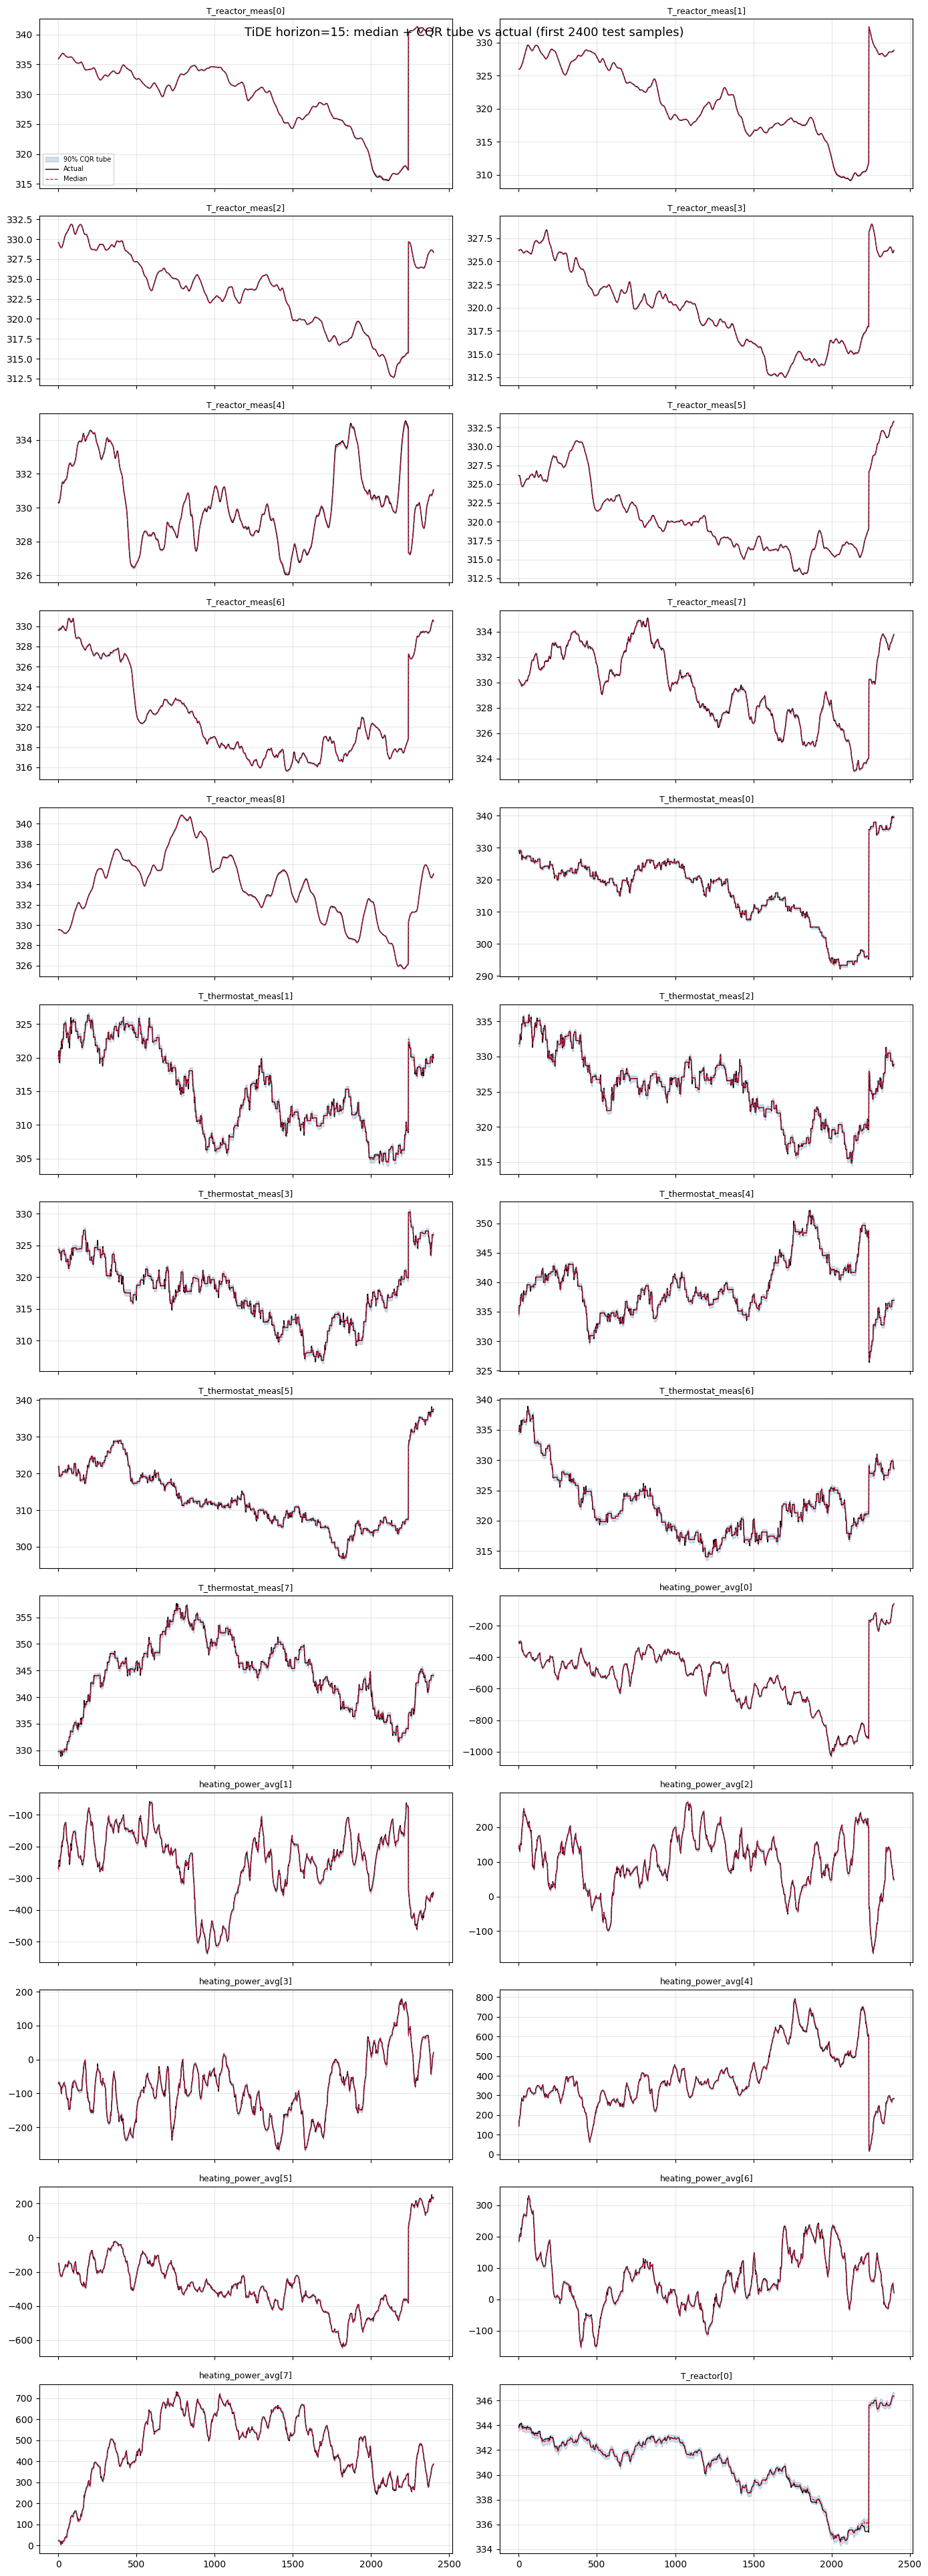

In [13]:
# Cell 13 -- Predictions + Tube plots -- 
for plot_h in [1, M]:
    hi = plot_h - 1
    med_h = median[:, hi, :]; lo_h = lower_cqr[:, hi, :]; up_h = upper_cqr[:, hi, :]; gt_h = y_phys[:, hi, :]
    n_plot = min(2400, med_h.shape[0]); t = np.arange(n_plot)
    n_cols = 2; n_rows = (n_outputs + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows), sharex=True)
    axes = axes.flatten()
    for i in range(n_outputs):
        ax = axes[i]
        ax.fill_between(t, lo_h[:n_plot, i], up_h[:n_plot, i], color='steelblue', alpha=0.25, label='90% CQR tube')
        ax.plot(t, gt_h[:n_plot, i],  color='black',   lw=1.0, label='Actual')
        ax.plot(t, med_h[:n_plot, i], color='crimson', lw=0.9, ls='--', label='Median')
        ax.set_title(label_names[i], fontsize=9); ax.grid(True, alpha=0.3)
        if i == 0: ax.legend(fontsize=7)
    for ax in axes[n_outputs:]: ax.set_visible(False)
    fig.suptitle(f'TiDE horizon={plot_h}: median + CQR tube vs actual (first {n_plot} test samples)', fontsize=13)
    fig.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_DIR, f'test_tube_h{plot_h}.png'), dpi=150)
    plt.show()

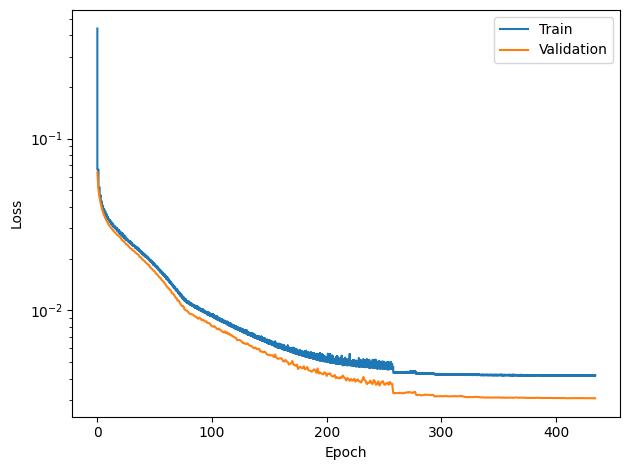

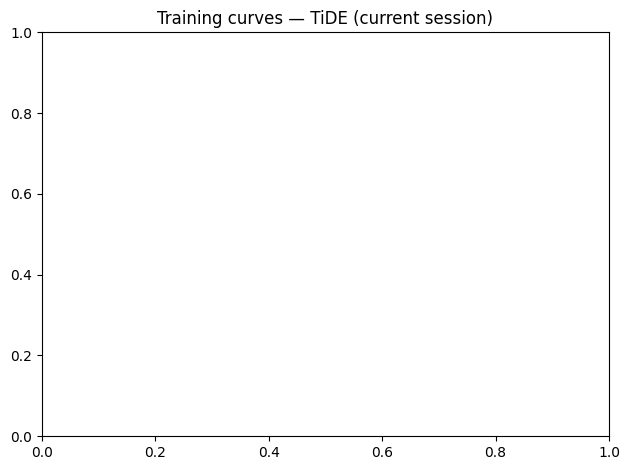

In [14]:
# Cell 14 -- training curves
EVAL_VERSION = None  # None = current session | 'version_0' = reload from Models_TiDE/
if EVAL_VERSION is None:
    _vd = get_latest_version_dir(os.path.join(LOG_DIR, EXPERIMENT))
    _title = f'Training curves — {EXPERIMENT} (current session)'
else:
    _vd = os.path.join(MODELS_BASE, EVAL_VERSION)
    _title = f'Training curves — {EVAL_VERSION}'
_metrics = os.path.join(_vd, 'metrics.csv')
if not os.path.exists(_metrics):
    print(f'metrics.csv not found at {_metrics}')
else:
    visualize_training_logs(_vd); plt.title(_title); plt.tight_layout(); plt.show()

Pooled AR eval over 77 test sims | N=160,853 rows (k>=150)

band            overall   width    reactor  thermosta    heating  T_reactor
  raw             0.863    6.46      0.792      0.925      0.907      0.650
  CQR(1-shot)     0.712    4.64      0.457      0.894      0.806      0.810
  AR-CQR          0.896    6.40      0.888      0.900      0.905      0.870
  AR-CQR(step)    0.901    6.36      0.897      0.900      0.910      0.867
  safety          0.927    6.50      0.979      0.900      0.905      0.870
  target           0.90
  expect: CQR(1-shot) under-covers; AR-CQR ~target overall but reactor heterogeneous;
          AR-CQR(step) flatter vs step; safety lifts every reactor channel >= target.

Per-output coverage across test sims  (mean / min / max):
              output  ARCQR_mean  ARCQR_min  ARCQR_max  step_mean  safety_mean  safety_min
   T_reactor_meas[0]       0.913      0.416      1.000      0.926        0.993       0.771
   T_reactor_meas[1]       0.900      0.448    

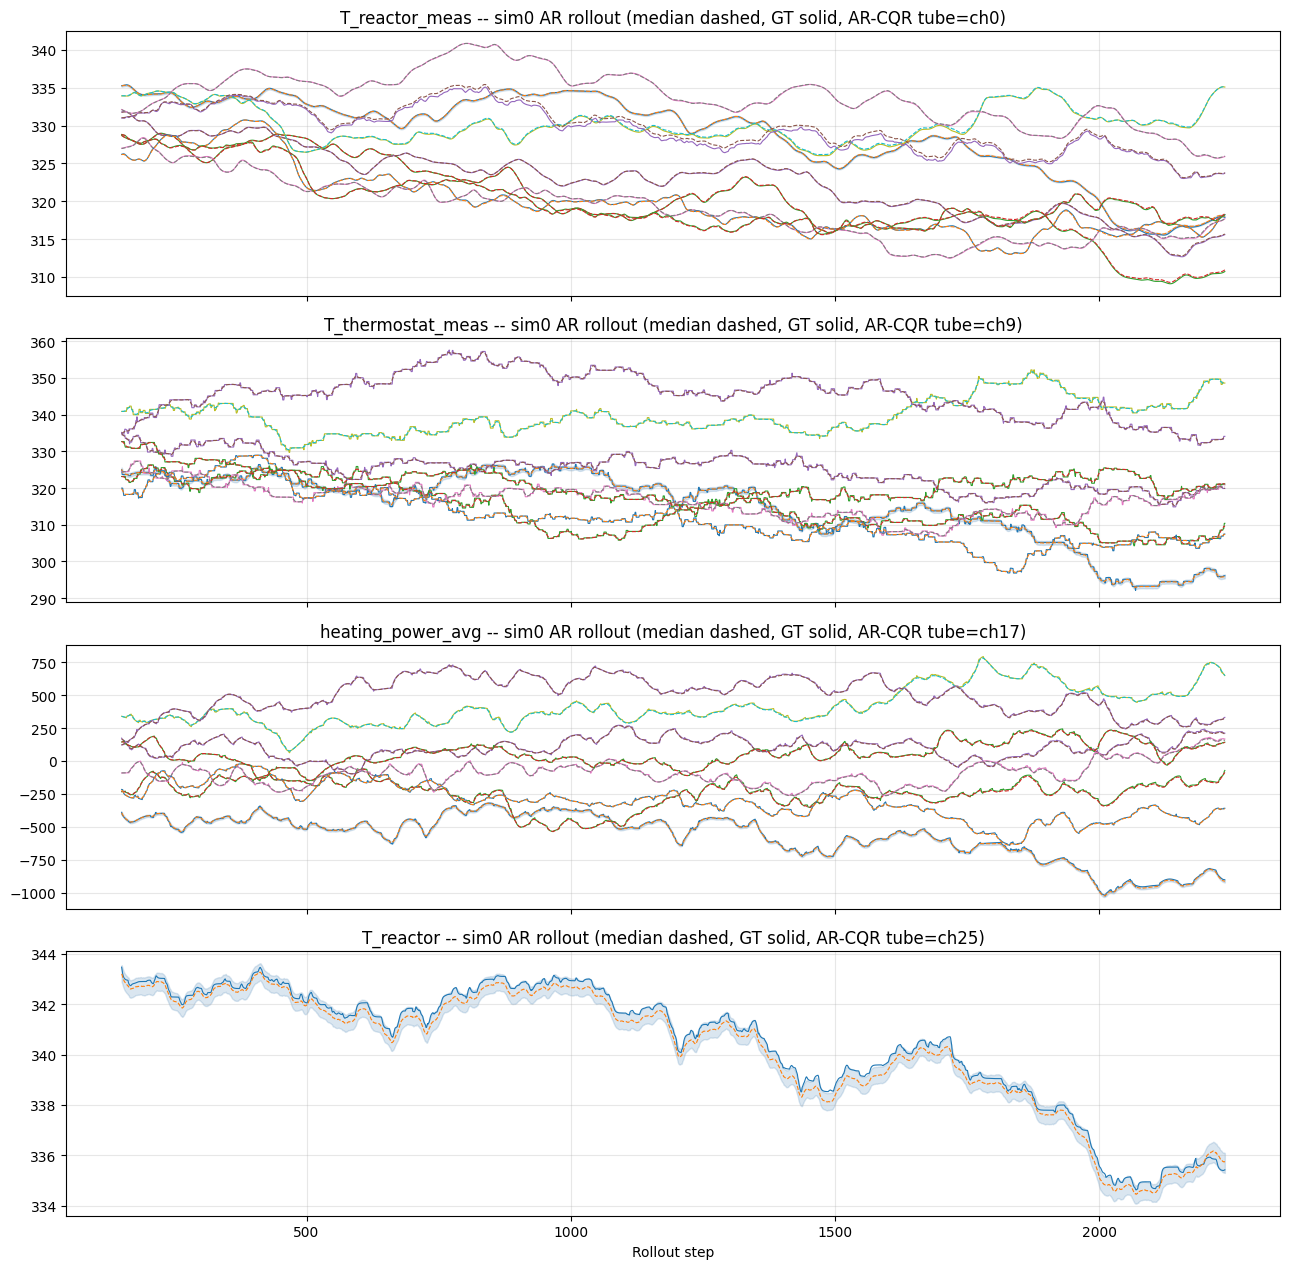

In [15]:
# Cell 15 -- AR rollout evaluation POOLED OVER ALL TEST SIMS (5 bands)
import pandas as pd
_msa_fs = load_scaler_params(os.path.join(MODEL_SAVE_DIR, 'msa_feature_scaler.yml'))

# One AR rollout per test sim, pooled (steps k >= BURN_IN), aligned via split_info.
coll_te = collect_ar_rollouts(
    model, X_test, y_test, split_info['test_sim_counts'],
    feature_scaler_params=_msa_fs, label_scaler_params=label_scaler,
    state_group_dims=STATE_GROUP_DIMS, n_ctrl_dims=N_CTRL_DIMS,
    M=M, base_output_dim=n_outputs, quantiles=TAU, device=DEVICE, burn_in=BURN_IN)

lo0, up0 = coll_te['lower'], coll_te['upper']
med, gt  = coll_te['median'], coll_te['ground_truth']
sim_idx, step_idx = coll_te['sim_idx'], coll_te['step_idx']
n_test_sims = coll_te['n_sims_used']

# Map each pooled row to its step-bin using the SAME edges as calibration.
bin_ids_te = step_bin_ids(step_idx, n_bins, bin_width=BIN_WIDTH, burn_in=BURN_IN)
lo_step, up_step = apply_cqr_stepwise(lo0, up0, q_hat_ar_stepwise, bin_ids_te)

bands = {
    'raw':          (lo0,                    up0),
    'CQR(1-shot)':  (lo0 - q_hat[0],         up0 + q_hat[0]),
    'AR-CQR':       (lo0 - q_hat_ar,         up0 + q_hat_ar),
    'AR-CQR(step)': (lo_step,                up_step),
    'safety':       (lo0 - q_hat_ar_safety,  up0 + q_hat_ar_safety),
}
inside_by_band = {nm: ((gt >= lo) & (gt <= up)) for nm, (lo, up) in bands.items()}

print(f'Pooled AR eval over {n_test_sims} test sims | N={gt.shape[0]:,} rows (k>={BURN_IN})')
print(f"\n{'band':<14}{'overall':>9}{'width':>8}" + ''.join(f'{g[:9]:>11}' for g in GROUPS))
group_idx = {g: list(range(sl.start, sl.stop)) for g, sl in GROUPS.items()}
for name, (lo, up) in bands.items():
    inside = inside_by_band[name]
    row = f"  {name:<12}{inside.mean():9.3f}{(up - lo).mean():8.2f}"
    for g, idxs in group_idx.items():
        row += f'{inside[:, idxs].mean():11.3f}'
    print(row)
print(f"  {'target':<12}{1-ALPHA:9.2f}")
print('  expect: CQR(1-shot) under-covers; AR-CQR ~target overall but reactor heterogeneous;')
print('          AR-CQR(step) flatter vs step; safety lifts every reactor channel >= target.')

# Per-output coverage as mean across test sims with min/max (heterogeneity explicit).
def per_sim_cov(inside):
    out = np.zeros((n_test_sims, inside.shape[1]))
    for s in range(n_test_sims):
        out[s] = inside[sim_idx == s].mean(axis=0)
    return out

psc = {nm: per_sim_cov(inside_by_band[nm]) for nm in ['AR-CQR', 'AR-CQR(step)', 'safety']}
rows = []
for i, nm in enumerate(label_names):
    rows.append({
        'output': nm,
        'ARCQR_mean': psc['AR-CQR'][:, i].mean(),
        'ARCQR_min':  psc['AR-CQR'][:, i].min(),
        'ARCQR_max':  psc['AR-CQR'][:, i].max(),
        'step_mean':  psc['AR-CQR(step)'][:, i].mean(),
        'safety_mean': psc['safety'][:, i].mean(),
        'safety_min':  psc['safety'][:, i].min(),
    })
cov_tbl = pd.DataFrame(rows)
print('\nPer-output coverage across test sims  (mean / min / max):')
print(cov_tbl.round(3).to_string(index=False))
cov_tbl.to_csv(os.path.join(MODEL_SAVE_DIR, 'ar_coverage_per_output.csv'), index=False)
print(f'Saved ar_coverage_per_output.csv to {MODEL_SAVE_DIR}')

# Representative single-sim tube plot (sim 0) for the AR-CQR band.
from collections import OrderedDict
m0 = sim_idx == 0
t0 = step_idx[m0]
lo_ar, up_ar = bands['AR-CQR']
groups_plot = OrderedDict()
for i, nm in enumerate(label_names):
    groups_plot.setdefault(nm.rsplit('[', 1)[0].rstrip('_'), []).append(i)

fig, axes = plt.subplots(len(groups_plot), 1, figsize=(13, 3.2 * len(groups_plot)), sharex=True)
if len(groups_plot) == 1: axes = [axes]
for ax, (gname, idxs) in zip(axes, groups_plot.items()):
    i0 = idxs[0]
    ax.fill_between(t0, lo_ar[m0, i0], up_ar[m0, i0], color='steelblue', alpha=0.2)
    for i in idxs:
        ax.plot(t0, gt[m0, i],  lw=0.8)
        ax.plot(t0, med[m0, i], lw=0.8, ls='--')
    ax.set_title(f'{gname} -- sim0 AR rollout (median dashed, GT solid, AR-CQR tube=ch{i0})')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Rollout step')
fig.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'tide_ar_rollout.png'), dpi=150)
plt.show()

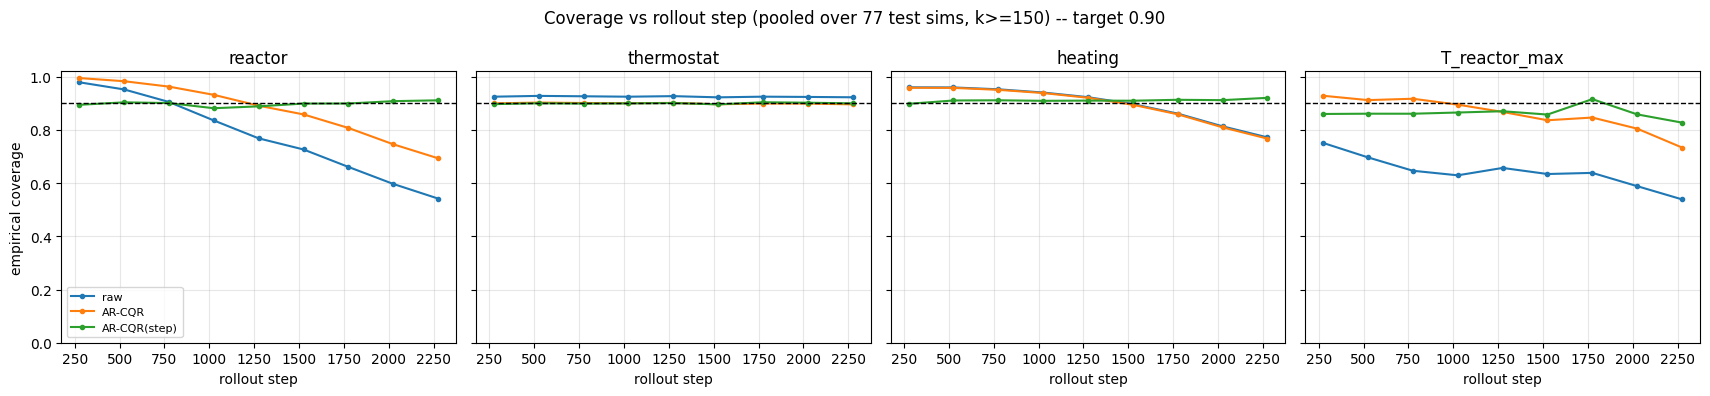

In [16]:
# Cell 16 -- Coverage-vs-step diagnostic (pooled over test sims, per group)
# Constant bands should over-cover early and under-cover late (drift); the
# step-adaptive band should stay ~flat at the target.
bin_centers = bin_edges + BIN_WIDTH / 2.0
diag_bands = ['raw', 'AR-CQR', 'AR-CQR(step)']

fig, axes = plt.subplots(1, len(GROUPS), figsize=(4.3 * len(GROUPS), 4), sharey=True)
if len(GROUPS) == 1: axes = [axes]
for ax, (gname, sl) in zip(axes, GROUPS.items()):
    gidx = list(range(sl.start, sl.stop))
    for bname in diag_bands:
        inside_g = inside_by_band[bname][:, gidx]            # (N, |g|)
        cov_by_bin = np.array([
            inside_g[bin_ids_te == b].mean() if np.any(bin_ids_te == b) else np.nan
            for b in range(n_bins)])
        ax.plot(bin_centers, cov_by_bin, marker='o', ms=3, label=bname)
    ax.axhline(1 - ALPHA, ls='--', color='k', lw=1)
    ax.set_title(gname); ax.set_xlabel('rollout step'); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.02)
axes[0].set_ylabel('empirical coverage')
axes[0].legend(fontsize=8, loc='lower left')
fig.suptitle(f'Coverage vs rollout step (pooled over {n_test_sims} test sims, k>={BURN_IN}) '
             f'-- target {1-ALPHA:.2f}', fontsize=12)
fig.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'ar_coverage_vs_step.png'), dpi=150)
plt.show()